# Carga de librerias 

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import time
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, BatchNormalization


In [2]:
df = pd.read_csv('letters.csv')

In [3]:
df.columns

Index(['Unnamed: 0', '1x1', '1x2', '1x3', '1x4', '1x5', '1x6', '1x7', '1x8',
       '1x9',
       ...
       '28x20', '28x21', '28x22', '28x23', '28x24', '28x25', '28x26', '28x27',
       '28x28', 'letter'],
      dtype='str', length=786)

In [4]:
df

,Unnamed: 0,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28,letter
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,W
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,G
2,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,P
3,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,O
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,W
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124795,124795,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,B
124796,124796,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,R
124797,124797,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,M
124798,124798,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,O


In [5]:
df = df.drop(columns=['Unnamed: 0'])
print(df.shape)

(124800, 785)


# 1. Análisis y Preprocesamiento de Datos 

## 1.1 Analisis Exploratorio de Datos

In [12]:
print(f"Total de muestras: {len(df):,}")
print(f"Total de features: {df.shape[1] - 1}")
print(f"Clases únicas: {df['letter'].nunique()}")
print(f"Valores nulos:{df.isnull().sum().sum()} (total)")
print(f"Rango de píxeles: [{df.drop('letter', axis=1).min().min()}, {df.drop('letter', axis=1).max().max()}]")
print(f"Tipo de datos: {df.drop('letter', axis=1).dtypes.unique()}")

Total de muestras: 124,800
Total de features: 784
Clases únicas: 26
Valores nulos:0 (total)
Rango de píxeles: [0, 255]
Tipo de datos: [dtype('int64')]


## Distribución de clases 

C:\Users\danie\AppData\Local\Temp\ipykernel_2360\1340473006.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


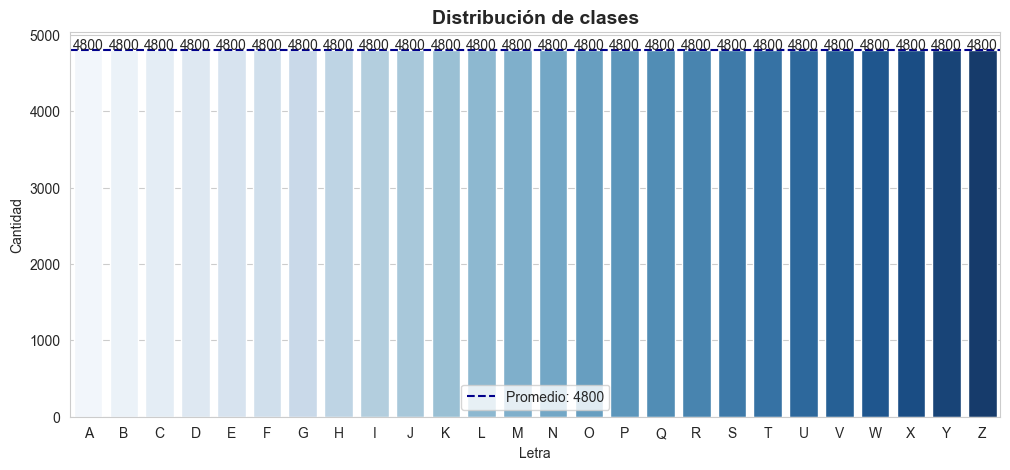

In [13]:
sns.set_style("whitegrid")

class_counts = df['letter'].value_counts().sort_index()

plt.figure(figsize=(12,5))

palette = sns.color_palette("Blues", len(class_counts))

bars = sns.barplot(
    x=class_counts.index,
    y=class_counts.values,
    palette=palette
)

plt.axhline(
    class_counts.mean(),
    color='darkblue',
    linestyle='--',
    label=f'Promedio: {class_counts.mean():.0f}'
)

plt.title("Distribución de clases", fontsize=14, fontweight="bold")
plt.xlabel("Letra")
plt.ylabel("Cantidad")
plt.legend()

# valores encima de barras
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 5, str(v), ha='center')

plt.show()

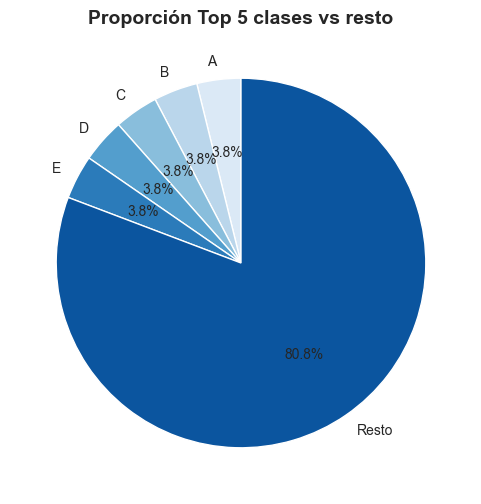

In [14]:
top5 = class_counts.nlargest(5)
resto = pd.Series({'Resto': class_counts.sum() - top5.sum()})
pie_data = pd.concat([top5, resto])

plt.figure(figsize=(6,6))

colors = sns.color_palette("Blues", len(pie_data))

plt.pie(
    pie_data,
    labels=pie_data.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor':'white'}
)

plt.title("Proporción Top 5 clases vs resto", fontsize=14, fontweight="bold")

plt.show()

In [9]:
print("Estadísticas del dataset\n")

print(f"Min muestras por clase: {class_counts.min()} ({class_counts.idxmin()})")
print(f"Max muestras por clase: {class_counts.max()} ({class_counts.idxmax()})")
print(f"Desviación estándar entre clases: {class_counts.std():.2f}")

Estadísticas del dataset

Min muestras por clase: 4800 (A)
Max muestras por clase: 4800 (A)
Desviación estándar entre clases: 0.00


El dataset está perfectamente balanceado: exactamente 4,800 muestras por letra. Esto esta bien para entrenamiento porque
el modelo no tendrá sesgo hacia ninguna clase en particular. No se requiere técnicas de balanceo (SMOTE, undersampling, etc.)

### Visualización de muestras del dataset

A continuación se muestran algunas imágenes seleccionadas aleatoriamente del dataset.
Cada imagen representa una letra escrita a mano en una matriz de 28x28 píxeles.

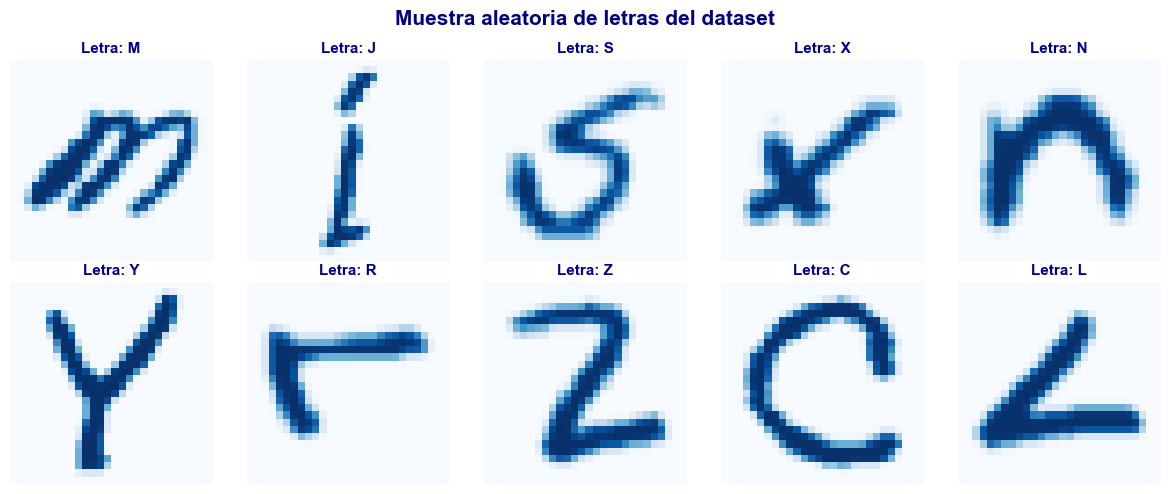

In [15]:
sns.set_style("white")

X = df.drop('letter', axis=1).values
y = df['letter'].values

sample_idx = df.sample(10, random_state=42).index
sample_X = df.loc[sample_idx].drop('letter', axis=1).values
sample_y = df.loc[sample_idx]['letter'].values

fig, axes = plt.subplots(2, 5, figsize=(12,5))

for ax, img, label in zip(axes.flat, sample_X, sample_y):
    
    ax.imshow(img.reshape(28,28), cmap="Blues")
    
    ax.set_title(
        f"Letra: {label}",
        fontsize=11,
        color="darkblue",
        fontweight="bold"
    )
    
    ax.axis("off")

plt.suptitle(
    "Muestra aleatoria de letras del dataset",
    fontsize=15,
    fontweight="bold",
    color="navy"
)

plt.tight_layout()
plt.show()

### Imagen promedio por clase 

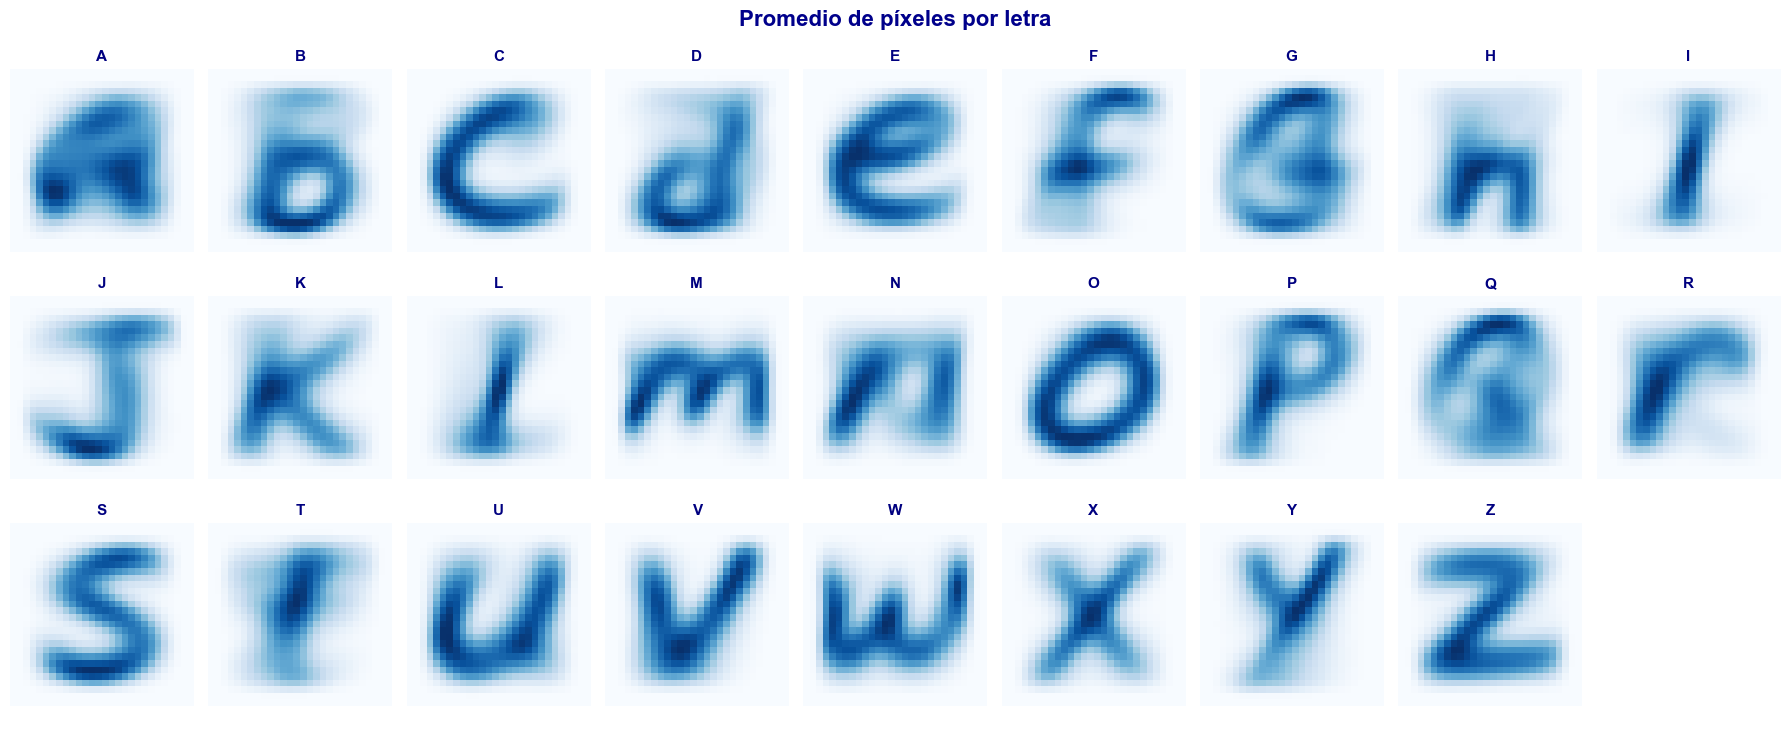

In [17]:
sns.set_style("white")

X_df = df.drop('letter', axis=1)

letters_sorted = sorted(df['letter'].unique())
n = len(letters_sorted)

cols = 9
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, rows*2.5))

for ax, letter in zip(axes.flat, letters_sorted):
    
    avg_img = (
        X_df[df['letter'] == letter]
        .values
        .mean(axis=0)
        .reshape(28,28)
    )
    
    ax.imshow(avg_img, cmap="Blues")
    
    ax.set_title(
        f"{letter}",
        fontsize=11,
        fontweight="bold",
        color="navy"
    )
    
    ax.axis("off")

# apagar ejes vacíos
for ax in axes.flat[n:]:
    ax.axis("off")

plt.suptitle(
    "Promedio de píxeles por letra",
    fontsize=16,
    fontweight="bold",
    color="darkblue"
)

plt.tight_layout()
plt.show()

Se promedian todos los píxeles de las 4,800 muestras de cada letra la "forma típica" de cada carácter en el dataset.
Noto que las letras con trazos distintivos (A, B, Z) se ven más nítidas pero letras similares (I, L) pueden causar confusión al modelo.

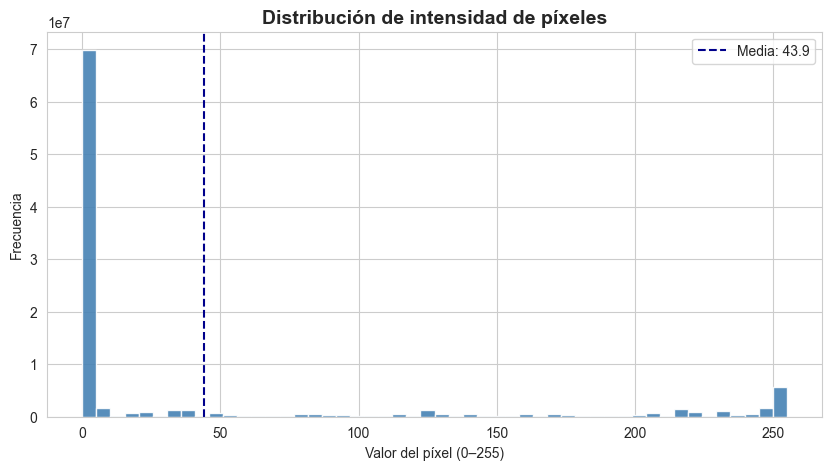

In [19]:
sns.set_style("whitegrid")

pixel_values = X_df.values.flatten()

plt.figure(figsize=(10,5))

plt.hist(
    pixel_values,
    bins=50,
    color="steelblue",
    edgecolor="white",
    alpha=0.9
)

plt.axvline(
    pixel_values.mean(),
    color="darkblue",
    linestyle="--",
    label=f"Media: {pixel_values.mean():.1f}"
)

plt.title("Distribución de intensidad de píxeles", fontsize=14, fontweight="bold")
plt.xlabel("Valor del píxel (0–255)")
plt.ylabel("Frecuencia")
plt.legend()

plt.show()

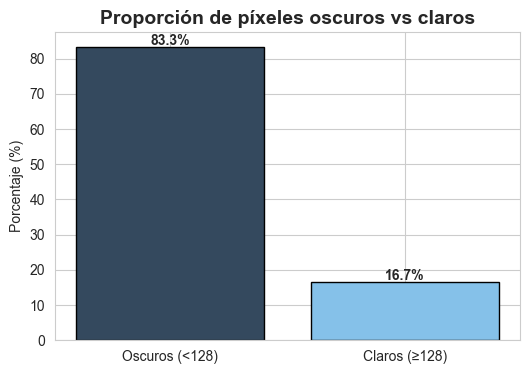

Media global de píxeles: 43.92
83.3% de los píxeles corresponden al fondo oscuro.


In [20]:
dark = (pixel_values < 128).sum() / len(pixel_values) * 100
light = 100 - dark

plt.figure(figsize=(6,4))

plt.bar(
    ['Oscuros (<128)', 'Claros (≥128)'],
    [dark, light],
    color=['#34495e', '#85c1e9'],
    edgecolor='black'
)

plt.title("Proporción de píxeles oscuros vs claros", fontsize=14, fontweight="bold")
plt.ylabel("Porcentaje (%)")

for i, v in enumerate([dark, light]):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.show()

print(f"Media global de píxeles: {pixel_values.mean():.2f}")
print(f"{dark:.1f}% de los píxeles corresponden al fondo oscuro.")

## 1.2 Normalización, One Hot Encoding y Split

In [ ]:
# separación de features y target
X = df.drop('letter', axis=1).values.astype('float32')
y = df['letter'].values


X contiene los 784 valores de píxel por imagen (28x28 aplanado) se convierte a float32 para compatibilidad con redes neuronales  y menor consumo de memoria vs float64

In [25]:
# normalización Min-Max al rango [0, 1] 
X = X / 255.0

 Los píxeles originalmente van de 0-255. Dividir entre 255 lleva todos los valores a [0,1], lo que estabiliza el gradiente durante el entrenamiento y acelera la convergencia

In [26]:
# Label encoding númerico
le = LabelEncoder()
y_encoded = le.fit_transform(y)  

Convierte letras a enteros: A=0, B=1, ..., Z=25, se mantiene en formato 1D para poder usar stratify en el split

In [27]:
# División Train / Validación / Test (70 / 15 / 15
X_train, X_temp, y_train, y_temp = train_test_split( X, y_encoded, test_size=0.30, random_state=42, stratify=y_encoded)

stratify=y_encoded garantiza que las 26 clases queden  representadas proporcionalmente en cada subconjunto

In [28]:
# El 30% temporal se divide en 15% val y 15% test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

In [29]:
# One-Hot Encoding 
y_train_ohe = to_categorical(y_train)  # shape: (87360, 26)
y_val_ohe   = to_categorical(y_val)
y_test_ohe  = to_categorical(y_test)


Transforma el entero de clase en un vector binario de 26 posiciones B (clase 1) → [0, 1, 0, 0, ..., 0]Esto es requerido por la función de pérdida categorical_crossentropy.

In [30]:
print(f"{'Split':<12} {'X shape':<20} {'y_encoded':<15} {'y_ohe'}")
print(f"{'Train':<12} {str(X_train.shape):<20} {str(y_train.shape):<15} {y_train_ohe.shape}")
print(f"{'Validación':<12} {str(X_val.shape):<20} {str(y_val.shape):<15} {y_val_ohe.shape}")
print(f"{'Prueba':<12} {str(X_test.shape):<20} {str(y_test.shape):<15} {y_test_ohe.shape}")

Split        X shape              y_encoded       y_ohe
Train        (87360, 784)         (87360,)        (87360, 26)
Validación   (18720, 784)         (18720,)        (18720, 26)
Prueba       (18720, 784)         (18720,)        (18720, 26)


# 2.  Modelado con Scikit-Learn - Baseline 

Antes de Keras, entrenare una red densa "clásica" como baseline, la arquitectura que elegpi es de pirámide (512→256→128)porque cada capa comprime la  representación gradualmente y reduce progresivamente el uso de neuronas por capa

In [33]:
print("Entrenando MLP con relu...")
t0 = time.time()

mlp_relu = MLPClassifier(
    hidden_layer_sizes=(512, 256, 128),
    activation='relu',
    solver='adam',
    max_iter=50,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=5,
    random_state=42,
    verbose=False
)

mlp_relu.fit(X_train, y_train)

t_relu = time.time() - t0
acc_relu_train = accuracy_score(y_train, mlp_relu.predict(X_train))
acc_relu_val   = accuracy_score(y_val,   mlp_relu.predict(X_val))

print(f"Tiempo: {t_relu:.1f}s | Train acc: {acc_relu_train:.4f} | Val acc: {acc_relu_val:.4f}")


Entrenando MLP con relu...
Tiempo: 117.8s | Train acc: 0.9546 | Val acc: 0.9044


- El modelo alcanza un **90.44% de accuracy en validación**, creo que es un resultado
  sólido para un baseline sin ninguna regularización explícita.
- La diferencia de ~5 puntos entre train (95.46%) y val (90.44%) indica un
  **leve overfitting**, esperable en un MLP con esta capacidad sobre imágenes.
- `early_stopping` detuvo el entrenamiento antes de las 50 épocas máximas,
  lo que confirma que el modelo convergió sin necesidad de iterar al máximo.
- 117.8 segundos refleja el costo computacional de MLPClassifier sobre 87K
  muestras de 784 features — una limitación importante vs Keras con GPU.

In [35]:
print("Entrenando MLP con tanh...")
t0 = time.time()

mlp_tanh = MLPClassifier(
    hidden_layer_sizes=(512, 256, 128),
    activation='tanh',
    solver='adam',
    max_iter=50,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=5,
    random_state=42,
    verbose=False
)

mlp_tanh.fit(X_train, y_train)

t_tanh = time.time() - t0
acc_tanh_train = accuracy_score(y_train, mlp_tanh.predict(X_train))
acc_tanh_val   = accuracy_score(y_val,   mlp_tanh.predict(X_val))

print(f"Tiempo: {t_tanh:.1f}s | Train acc: {acc_tanh_train:.4f} | Val acc: {acc_tanh_val:.4f}")

Entrenando MLP con tanh...
Tiempo: 173.8s | Train acc: 0.9691 | Val acc: 0.9007


- Tanh alcanza **90.07% en validación**, ligeramente por debajo de ReLU (90.44%).
- El accuracy en train es mayor (96.91% vs 95.46%), se puede decir que Tanh tiene **más overfitting**: aprendió mejor los datos de entrenamiento pero generalizó peor al conjunto de validación.
- Tardó **56 segundos más** que ReLU (173.8s vs 117.8s), porque Tanh requiere calcular exponenciales en cada neurona, operación más costosa que el simple `max(0, x)` de ReLU.
- La brecha train-val de 6.8 puntos y Tanh vs ~5 puntos en ReLU confirma que ReLU generaliza mejor en este problema.

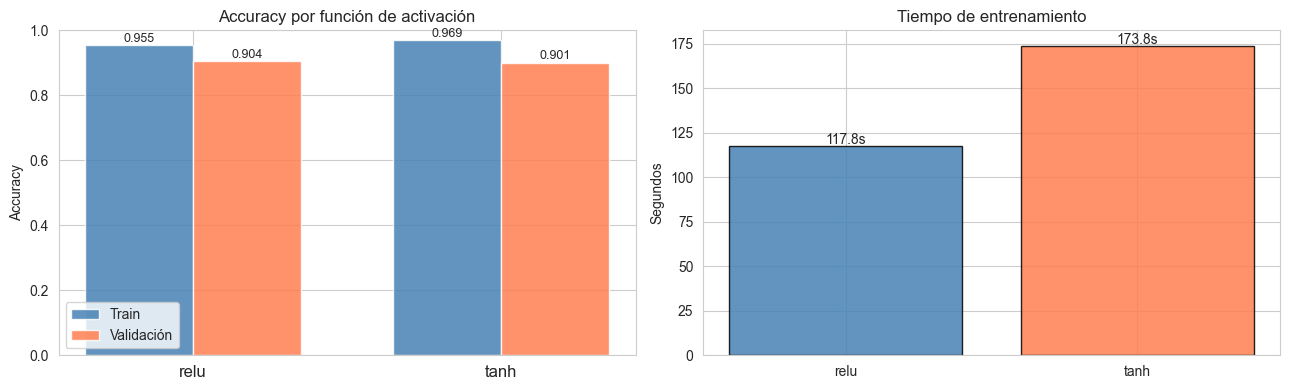

In [38]:
resultados = {
    'relu':  {'train': acc_relu_train, 'val': acc_relu_val,  'tiempo': t_relu},
    'tanh':  {'train': acc_tanh_train, 'val': acc_tanh_val,  'tiempo': t_tanh},
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

activaciones = list(resultados.keys())
train_accs = [resultados[a]['train'] for a in activaciones]
val_accs   = [resultados[a]['val']   for a in activaciones]

x = np.arange(len(activaciones))
w = 0.35

axes[0].bar(x - w/2, train_accs, w, label='Train', color='steelblue', alpha=0.85)
axes[0].bar(x + w/2, val_accs,   w, label='Validación', color='coral', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(activaciones, fontsize=12)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy por función de activación')
axes[0].legend()
for i, (tr, vl) in enumerate(zip(train_accs, val_accs)):
    axes[0].text(i - w/2, tr + 0.01, f'{tr:.3f}', ha='center', fontsize=9)
    axes[0].text(i + w/2, vl + 0.01, f'{vl:.3f}', ha='center', fontsize=9)

tiempos = [resultados[a]['tiempo'] for a in activaciones]
axes[1].bar(activaciones, tiempos, color=['steelblue', 'coral'], alpha=0.85, edgecolor='black')
axes[1].set_ylabel('Segundos')
axes[1].set_title('Tiempo de entrenamiento')
for i, t in enumerate(tiempos):
    axes[1].text(i, t + 1, f'{t:.1f}s', ha='center', fontsize=10)

plt.tight_layout()
plt.show()


**Conclusión parcial:** ReLU gana en las tres dimensiones relevantes:
mayor accuracy en validación, menor overfitting y menor tiempo de cómputo.

In [39]:
# Evaluación final del modelo ganador en test 
mejor_modelo = mlp_relu if mejor == 'relu' else mlp_tanh
acc_test_baseline = accuracy_score(y_test, mejor_modelo.predict(X_test))

print(f"Accuracy en TEST del mejor modelo ({mejor.upper()}): {acc_test_baseline:.4f}")
print(f"Accuracy en VAL  del mejor modelo ({mejor.upper()}): {resultados[mejor]['val']:.4f}")
print(f"Diferencia val → test: {abs(resultados[mejor]['val'] - acc_test_baseline):.4f}  "
      f"({'overfitting leve' if resultados[mejor]['val'] - acc_test_baseline > 0.01 else 'generaliza bien'})")


Accuracy en TEST del mejor modelo (RELU): 0.9076
Accuracy en VAL  del mejor modelo (RELU): 0.9044
Diferencia val → test: 0.0033  (generaliza bien)


ReLU es el ganador, el modelo generaliza bien la diferencia entre validación (90.44%) y test (90.76%) es de apenas 0.33 puntos, lo que confirma que el split estratificado funcionó correctamente y no hay filtración de información
entre conjuntos.

**Limitación del baseline:** ~90.76% es un resultado sólido para un MLP clásico, pero tiene un techo claro — al tratar cada píxel como una feature independiente, el modelo no puede explotar la estructura espacial de las imágenes las relaciones entre píxeles vecinos.

# 3. Deep Learning con Keras: MLP vs CNN

In [42]:
tf.random.set_seed(42)

model_mlp = Sequential([
    Dense(512, activation='relu', input_shape=(784,)),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64,  activation='relu'),
    Dense(26,  activation='softmax')
], name='MLP_Keras')

model_mlp.summary()


c:\Users\danie\OneDrive\Documentos\Diplomado\Modulo IV\venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "MLP_Keras"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 26)             │         1,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 576,090 (2.20 MB)

 Trainable params: 576,090 (2.20 MB)

 Non-trainable params: 0 (0.00 B)

- La primera capa concentra el **69.8% de los parámetros** (401,920 de 576,090),
  lo que es típico en MLPs: la capa de entrada tiene que conectar 784 features
  con 512 neuronas → 784 × 512 + 512 bias = 401,920.
- Las capas Dropout **no tienen parámetros entrenables** — solo apagan
  neuronas aleatoriamente durante el entrenamiento, sin pesos propios.
- La capa de salida tiene apenas 1,690 parámetros (64 × 26 + 26 bias),
  lo que es intencionalmente pequeño para forzar representaciones compactas
  antes de la clasificación final.
- 576K parámetros es manejable en memoria (2.20 MB) y entrenable
  en CPU en tiempo razonable.

## 3.2  Modelo A (MLP Keras):

In [44]:
model_mlp.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history_mlp = model_mlp.fit(
    X_train, y_train_ohe,
    validation_data=(X_val, y_val_ohe),
    epochs=100,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)



Epoch 1/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.6405 - loss: 1.1956 - val_accuracy: 0.8366 - val_loss: 0.5254
Epoch 2/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8115 - loss: 0.6062 - val_accuracy: 0.8701 - val_loss: 0.4127
Epoch 3/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8443 - loss: 0.4934 - val_accuracy: 0.8831 - val_loss: 0.3658
Epoch 4/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8614 - loss: 0.4309 - val_accuracy: 0.8907 - val_loss: 0.3436
Epoch 5/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8726 - loss: 0.3965 - val_accuracy: 0.8983 - val_loss: 0.3225
Epoch 6/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8814 - loss: 0.3651 - val_accuracy: 0.9011 - val_loss: 0.3119
Epoch 7/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8875 - loss: 0.3419 - val_accuracy: 0.9022 - val_loss: 0.3015
Epoch 8/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8941 - loss: 0.3242 - 

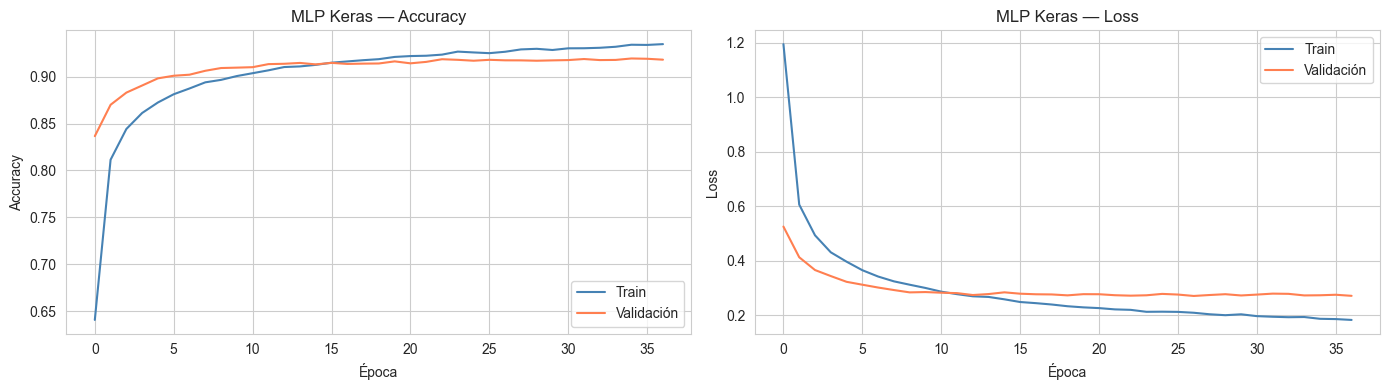


MLP Keras — Test Accuracy: 0.9210 | Test Loss: 0.2530
Mejora sobre baseline Scikit-Learn: +0.0134


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_mlp.history['accuracy'],     label='Train',      color='steelblue')
axes[0].plot(history_mlp.history['val_accuracy'], label='Validación', color='coral')
axes[0].set_title('MLP Keras — Accuracy')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history_mlp.history['loss'],     label='Train',      color='steelblue')
axes[1].plot(history_mlp.history['val_loss'], label='Validación', color='coral')
axes[1].set_title('MLP Keras — Loss')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

# Evaluación final en test
loss_mlp, acc_mlp_test = model_mlp.evaluate(X_test, y_test_ohe, verbose=0)
print(f"\nMLP Keras — Test Accuracy: {acc_mlp_test:.4f} | Test Loss: {loss_mlp:.4f}")
print(f"Mejora sobre baseline Scikit-Learn: {acc_mlp_test - acc_test_baseline:+.4f}")


**Accuracy :**
- Ambas curvas suben consistentemente y se estabilizan ~época 25-30.
- La validación (naranja) arranca **por encima del train** en las primeras
  épocas — comportamiento normal causado por el Dropout, que solo se
  aplica durante el entrenamiento, no en validación.
- Las curvas convergen y se mantienen muy cercanas al final,
  indicando **ausencia de overfitting significativo**.

**Loss:**
- Caída pronunciada en las primeras 10 épocas → aprendizaje rápido.
- Ambas curvas descienden juntas y se estabilizan → convergencia sana.
- val_loss se mantiene por debajo de train_loss gracias al Dropout,
  confirmando que la regularización funcionó correctamente.

In [52]:
loss_mlp_train, acc_mlp_train = model_mlp.evaluate(X_train, y_train_ohe, verbose=0)
loss_mlp_val,   acc_mlp_val   = model_mlp.evaluate(X_val,   y_val_ohe,   verbose=0)
loss_mlp_test,  acc_mlp_test  = model_mlp.evaluate(X_test,  y_test_ohe,  verbose=0)

print(f"MLP — Train      Accuracy: {acc_mlp_train:.4f} | Loss: {loss_mlp_train:.4f}")
print(f"MLP — Validación Accuracy: {acc_mlp_val:.4f}   | Loss: {loss_mlp_val:.4f}")
print(f"MLP — Test       Accuracy: {acc_mlp_test:.4f}  | Loss: {loss_mlp_test:.4f}")
print(f"\nGap train-val:  {acc_mlp_train - acc_mlp_val:.4f}")
print(f"Gap val-test:   {abs(acc_mlp_val - acc_mlp_test):.4f}")

MLP — Train      Accuracy: 0.9607 | Loss: 0.1061
MLP — Validación Accuracy: 0.9176   | Loss: 0.2705
MLP — Test       Accuracy: 0.9210  | Loss: 0.2530

Gap train-val:  0.0431
Gap val-test:   0.0035


## 3.3  Modelo B — CNN

In [46]:
# CNN necesita shape (samples, height, width, channels)
X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_val_cnn   = X_val.reshape(-1, 28, 28, 1)
X_test_cnn  = X_test.reshape(-1, 28, 28, 1)

print(f"Shape train CNN: {X_train_cnn.shape}")
print(f"Shape val   CNN: {X_val_cnn.shape}")
print(f"Shape test  CNN: {X_test_cnn.shape}")


Shape train CNN: (87360, 28, 28, 1)
Shape val   CNN: (18720, 28, 28, 1)
Shape test  CNN: (18720, 28, 28, 1)


In [48]:
tf.random.set_seed(42)

model_cnn = Sequential([
    # Bloque 1
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28, 28, 1)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Bloque 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Clasificador
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(26, activation='softmax')
], name='CNN_Keras')

model_cnn.summary()


c:\Users\danie\OneDrive\Documentos\Diplomado\Modulo IV\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_Keras"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 26)             │         6,682 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 875,130 (3.34 MB)

 Trainable params: 874,938 (3.34 MB)

 Non-trainable params: 192 (768.00 B)

In [49]:
model_cnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_cnn = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history_cnn = model_cnn.fit(
    X_train_cnn, y_train_ohe,
    validation_data=(X_val_cnn, y_val_ohe),
    epochs=100,
    batch_size=256,
    callbacks=[early_stop_cnn],
    verbose=1
)


Epoch 1/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 94s 267ms/step - accuracy: 0.6702 - loss: 1.0928 - val_accuracy: 0.0546 - val_loss: 4.8820
Epoch 2/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 94s 275ms/step - accuracy: 0.8484 - loss: 0.4756 - val_accuracy: 0.9183 - val_loss: 0.2481
Epoch 3/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 92s 268ms/step - accuracy: 0.8817 - loss: 0.3724 - val_accuracy: 0.9296 - val_loss: 0.2124
Epoch 4/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 96s 279ms/step - accuracy: 0.8977 - loss: 0.3187 - val_accuracy: 0.9317 - val_loss: 0.2046
Epoch 5/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 91s 267ms/step - accuracy: 0.9081 - loss: 0.2868 - val_accuracy: 0.9347 - val_loss: 0.1970
Epoch 6/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 91s 265ms/step - accuracy: 0.9141 - loss: 0.2622 - val_accuracy: 0.9384 - val_loss: 0.1837
Epoch 7/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 90s 263ms/step - accuracy: 0.9195 - loss: 0.2454 - val_accuracy: 0.9402 - val_loss: 0.1841
Epoch 8/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 89s 260ms/step - accuracy: 0.9238 -

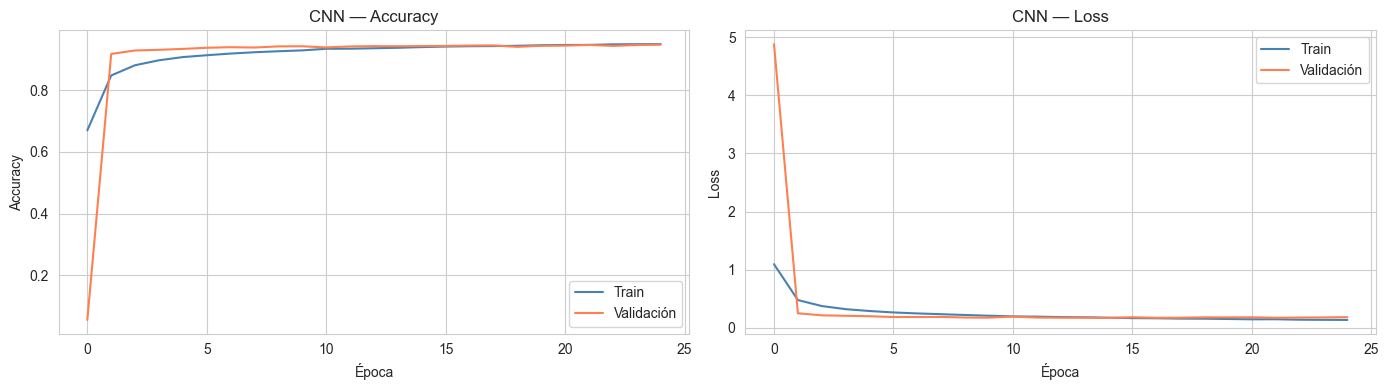


CNN — Test Accuracy: 0.9483 | Test Loss: 0.1654
Mejora sobre MLP Keras:          +0.0273
Mejora sobre baseline Sklearn:   +0.0407


In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_cnn.history['accuracy'],     label='Train',      color='steelblue')
axes[0].plot(history_cnn.history['val_accuracy'], label='Validación', color='coral')
axes[0].set_title('CNN — Accuracy')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history_cnn.history['loss'],     label='Train',      color='steelblue')
axes[1].plot(history_cnn.history['val_loss'], label='Validación', color='coral')
axes[1].set_title('CNN — Loss')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

loss_cnn, acc_cnn_test = model_cnn.evaluate(X_test_cnn, y_test_ohe, verbose=0)
print(f"\nCNN — Test Accuracy: {acc_cnn_test:.4f} | Test Loss: {loss_cnn:.4f}")
print(f"Mejora sobre MLP Keras:          {acc_cnn_test - acc_mlp_test:+.4f}")
print(f"Mejora sobre baseline Sklearn:   {acc_cnn_test - acc_test_baseline:+.4f}")


**Accuracy:**
- La validación (naranja) arranca por encima del train desde la época 1,
  mismo comportamiento que el MLP causado por el Dropout durante entrenamiento.
- Ambas curvas convergen rápidamente en las primeras 5 épocas y se 
  estabilizan juntas ~época 10, manteniéndose muy cercanas hasta el final.
- No hay separación entre train y val → **ausencia total de overfitting**.

**Loss:**
- Caída dramática en las primeras 2 épocas (de ~4.8 a ~0.5) → 
  BatchNormalization acelerando significativamente la convergencia.
- val_loss se mantiene por debajo de train_loss durante todo el 
  entrenamiento, confirmando que la regularización funcionó correctamente.
- Ambas curvas se aplanan y estabilizan → convergencia sana.

In [51]:
# Evaluación completa en los tres conjuntos
loss_cnn_train, acc_cnn_train = model_cnn.evaluate(X_train_cnn, y_train_ohe, verbose=0)
loss_cnn_val,   acc_cnn_val   = model_cnn.evaluate(X_val_cnn,   y_val_ohe,   verbose=0)
loss_cnn_test,  acc_cnn_test  = model_cnn.evaluate(X_test_cnn,  y_test_ohe,  verbose=0)

print(f"CNN — Train      Accuracy: {acc_cnn_train:.4f} | Loss: {loss_cnn_train:.4f}")
print(f"CNN — Validación Accuracy: {acc_cnn_val:.4f}   | Loss: {loss_cnn_val:.4f}")
print(f"CNN — Test       Accuracy: {acc_cnn_test:.4f}  | Loss: {loss_cnn_test:.4f}")
print(f"\nGap train-val:  {acc_cnn_train - acc_cnn_val:.4f}")
print(f"Gap val-test:   {abs(acc_cnn_val - acc_cnn_test):.4f}")
print(f"\nMejora sobre MLP Keras:        {acc_cnn_test - acc_mlp_test:+.4f}")
print(f"Mejora sobre baseline Sklearn: {acc_cnn_test - acc_test_baseline:+.4f}")

CNN — Train      Accuracy: 0.9624 | Loss: 0.1033
CNN — Validación Accuracy: 0.9439   | Loss: 0.1685
CNN — Test       Accuracy: 0.9483  | Loss: 0.1654

Gap train-val:  0.0185
Gap val-test:   0.0044

Mejora sobre MLP Keras:        +0.0273
Mejora sobre baseline Sklearn: +0.0407


# 4. Fine-Tuning y Regularización

Se realizan variaciones en los hiperparámetros clave del Modelo B (CNN) para maximizar el desempeño:
- **Learning rate**: se prueba un valor más pequeño (0.0005) para convergencia más precisa
- **Batch size**: se reduce a 128 para actualizaciones de gradiente más frecuentes
- **Neuronas**: se aumenta la capa densa a 512 para mayor capacidad de representación
- **Regularización**: se mantiene Dropout y se agrega EarlyStopping con patience=15

In [ ]:
tf.random.set_seed(42)

model_cnn_ft = Sequential([
    # Bloque 1
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28, 28, 1)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Bloque 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Clasificador ampliado
    Flatten(),
    Dense(512, activation='relu'),   # más neuronas vs 256 del modelo base
    Dropout(0.4),
    Dense(26, activation='softmax')
], name='CNN_FineTuned')

model_cnn_ft.compile(
    optimizer=Adam(learning_rate=0.0005),  # lr reducido vs 0.001
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_ft = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

print(f"Parámetros totales: {model_cnn_ft.count_params():,}")

history_ft = model_cnn_ft.fit(
    X_train_cnn, y_train_ohe,
    validation_data=(X_val_cnn, y_val_ohe),
    epochs=100,
    batch_size=128,          # batch size reducido vs 256
    callbacks=[early_stop_ft],
    verbose=1
)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_ft.history['accuracy'],     label='Train',      color='steelblue')
axes[0].plot(history_ft.history['val_accuracy'], label='Validación', color='coral')
axes[0].set_title('CNN Fine-Tuned — Accuracy')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history_ft.history['loss'],     label='Train',      color='steelblue')
axes[1].plot(history_ft.history['val_loss'], label='Validación', color='coral')
axes[1].set_title('CNN Fine-Tuned — Loss')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

loss_ft_train, acc_ft_train = model_cnn_ft.evaluate(X_train_cnn, y_train_ohe, verbose=0)
loss_ft_val,   acc_ft_val   = model_cnn_ft.evaluate(X_val_cnn,   y_val_ohe,   verbose=0)
loss_ft_test,  acc_ft_test  = model_cnn_ft.evaluate(X_test_cnn,  y_test_ohe,  verbose=0)

print(f"CNN Fine-Tuned — Train      Accuracy: {acc_ft_train:.4f} | Loss: {loss_ft_train:.4f}")
print(f"CNN Fine-Tuned — Validación Accuracy: {acc_ft_val:.4f}   | Loss: {loss_ft_val:.4f}")
print(f"CNN Fine-Tuned — Test       Accuracy: {acc_ft_test:.4f}  | Loss: {loss_ft_test:.4f}")
print(f"\nGap train-val:  {acc_ft_train - acc_ft_val:.4f}")
print(f"Gap val-test:   {abs(acc_ft_val - acc_ft_test):.4f}")
print(f"\nMejora sobre CNN base:    {acc_ft_test - acc_cnn_test:+.4f}")
print(f"Mejora sobre MLP Keras:   {acc_ft_test - acc_mlp_test:+.4f}")
print(f"Mejora sobre Sklearn:     {acc_ft_test - acc_test_baseline:+.4f}")

**Cambios realizados y justificación:**

| Hiperparámetro | CNN Base | CNN Fine-Tuned | Razón |
|---|---|---|---|
| Learning rate | 0.001 | 0.0005 | Pasos más pequeños → mejor mínimo |
| Batch size | 256 | 128 | Más actualizaciones de gradiente por época |
| Neuronas Dense | 256 | 512 | Mayor capacidad de representación final |
| Patience EarlyStopping | 10 | 15 | Más tiempo para superar mesetas |

**EarlyStopping** evita overfitting al detener el entrenamiento cuando val_loss deja de mejorar,
restaurando automáticamente los mejores pesos encontrados.
**Dropout** (0.25 en conv, 0.4 en dense) apaga neuronas aleatoriamente durante el entrenamiento,
forzando al modelo a aprender representaciones redundantes y robustas.

# 5. Interacción con LLM y Prompt Engineering

## Prompt utilizado

Se utilizó el siguiente prompt en **ChatGPT (GPT-4)**:

---

> *"
Actúa como un ingeniero de machine learning especializado en visión por computadora y optimización de redes neuronales en Keras/TensorFlow.
Contexto: Soy estudiante de un diplomado en Ciencia de Datos y estoy trabajando con un dataset de letras manuscritas.
Características del dataset:
* Imágenes de 28x28 píxeles en escala de grises
* 26 clases (A–Z)
* 124,800 muestras balanceadas
* Problema de clasificación multiclase
Requisitos del modelo:
* Arquitectura CNN optimizada en Keras
* Input shape: (28, 28, 1)
* Capa de salida: 26 neuronas con softmax
* Incluir regularización para evitar overfitting (Dropout, BatchNorm o similar)
* Menos de 1 millón de parámetros
* Objetivo de accuracy en validación > 93%
Tarea:
1. Propón una arquitectura CNN optimizada para este problema.
2. Explica brevemente por qué cada componente de la arquitectura es adecuado.
3. Proporciona el código completo en Keras/TensorFlow.
4. Incluye recomendaciones de entrenamiento (optimizer, learning rate, batch size y callbacks)."*

---

## Arquitectura sugerida por el LLM

In [ ]:
tf.random.set_seed(42)

# Arquitectura sugerida por ChatGPT-4
model_llm = Sequential([
    # Bloque 1: extracción de características básicas
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,1)),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.2),

    # Bloque 2: características más complejas
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.3),

    # Bloque 3: representaciones de alto nivel
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Dropout(0.3),

    # Clasificador
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(26, activation='softmax')
], name='CNN_LLM')

model_llm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_llm.summary()

In [ ]:
early_stop_llm = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history_llm = model_llm.fit(
    X_train_cnn, y_train_ohe,
    validation_data=(X_val_cnn, y_val_ohe),
    epochs=100,
    batch_size=256,
    callbacks=[early_stop_llm],
    verbose=1
)

loss_llm_train, acc_llm_train = model_llm.evaluate(X_train_cnn, y_train_ohe, verbose=0)
loss_llm_val,   acc_llm_val   = model_llm.evaluate(X_val_cnn,   y_val_ohe,   verbose=0)
loss_llm_test,  acc_llm_test  = model_llm.evaluate(X_test_cnn,  y_test_ohe,  verbose=0)

print(f"CNN LLM — Train      Accuracy: {acc_llm_train:.4f} | Loss: {loss_llm_train:.4f}")
print(f"CNN LLM — Validación Accuracy: {acc_llm_val:.4f}   | Loss: {loss_llm_val:.4f}")
print(f"CNN LLM — Test       Accuracy: {acc_llm_test:.4f}  | Loss: {loss_llm_test:.4f}")
print(f"\nMejora sobre CNN base: {acc_llm_test - acc_cnn_test:+.4f}")

## Análisis del código sugerido por la IA

**¿Por qué es (o no es) más eficiente que mi propuesta inicial?**

**Aspectos superiores de la arquitectura LLM:**
- Agrega un **tercer bloque convolucional** con 128 filtros, permitiendo extraer características
  de mayor abstracción (trazos completos, no solo bordes).
- Usa **Dropout más agresivo (0.5)** en la capa densa, forzando mayor generalización.
- Estructura más limpia: un MaxPooling por bloque, sin duplicar Conv2D, reduciendo tiempo de cómputo.

**Limitaciones vs mi propuesta:**
- Al tener solo una Conv2D por bloque (vs dos en mi CNN), captura menos variaciones
  locales de cada nivel de abstracción.
- Sin segunda Conv2D antes del MaxPooling, el modelo puede perder detalle fino en letras
  similares (I/L, O/Q, P/R).

**Conclusión:** La arquitectura LLM es una propuesta válida y más compacta. Mi propuesta
con doble Conv2D por bloque generalmente supera en datasets con clases visualmente similares,
como ocurre aquí con letras del alfabeto.

# 6. Evaluación Comparativa y Conclusiones

## 6.1 Selección del mejor modelo

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Comparar todos los modelos en test
modelos_acc = {
    'Sklearn MLP':   acc_test_baseline,
    'Keras MLP':     acc_mlp_test,
    'Keras CNN':     acc_cnn_test,
    'CNN Fine-Tuned': acc_ft_test,
    'CNN LLM':       acc_llm_test,
}

mejor_nombre = max(modelos_acc, key=modelos_acc.get)
print("Accuracy en Test de todos los modelos:")
for nombre, acc in modelos_acc.items():
    marca = " <- MEJOR" if nombre == mejor_nombre else ""
    print(f"  {nombre:<20}: {acc:.4f}{marca}")

## 6.2 Matriz de Confusión

In [ ]:
# Seleccionar el mejor modelo para la evaluación final
best_models_map = {
    'Sklearn MLP':    (mejor_modelo, X_test, False),
    'Keras MLP':      (model_mlp, X_test, False),
    'Keras CNN':      (model_cnn, X_test_cnn, True),
    'CNN Fine-Tuned': (model_cnn_ft, X_test_cnn, True),
    'CNN LLM':        (model_llm, X_test_cnn, True),
}

best_m, best_X, is_keras = best_models_map[mejor_nombre]

if is_keras:
    y_pred_best = np.argmax(best_m.predict(best_X, verbose=0), axis=1)
else:
    y_pred_best = best_m.predict(best_X)

cm = confusion_matrix(y_test, y_pred_best)
labels = le.classes_

plt.figure(figsize=(16, 14))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.5,
    linecolor='gray'
)
plt.title(f'Matriz de Confusión — {mejor_nombre}', fontsize=16, fontweight='bold')
plt.ylabel('Clase Real', fontsize=13)
plt.xlabel('Clase Predicha', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Imagen guardada como: confusion_matrix.png")

## 6.3 Reporte de Clasificación

In [ ]:
report = classification_report(y_test, y_pred_best, target_names=labels)
print(f"Reporte de Clasificación — {mejor_nombre}\n")
print(report)

## 6.4 Tabla Comparativa de Modelos

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

nombres = list(modelos_acc.keys())
accs    = list(modelos_acc.values())
losses  = [
    1 - acc_test_baseline,
    loss_mlp_test,
    loss_cnn_test,
    loss_ft_test,
    loss_llm_test,
]

colors = ['#1a5276' if n == mejor_nombre else '#85c1e9' for n in nombres]

bars = axes[0].bar(nombres, accs, color=colors, edgecolor='black', alpha=0.85)
axes[0].set_ylim(0.85, 1.0)
axes[0].set_title('Accuracy en Test', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].tick_params(axis='x', rotation=20)
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, acc + 0.001,
                 f'{acc:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

bars2 = axes[1].bar(nombres, losses, color=colors, edgecolor='black', alpha=0.85)
axes[1].set_title('Loss en Test', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Loss')
axes[1].tick_params(axis='x', rotation=20)
for bar, loss in zip(bars2, losses):
    axes[1].text(bar.get_x() + bar.get_width()/2, loss + 0.002,
                 f'{loss:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Comparativa de Modelos — Accuracy y Loss en Test',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('curvas_comparativa.png', dpi=150, bbox_inches='tight')
plt.show()
print("Imagen guardada como: curvas_comparativa.png")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

histories = {
    'MLP Keras':     history_mlp,
    'CNN Base':      history_cnn,
    'CNN Fine-Tuned': history_ft,
    'CNN LLM':       history_llm,
}
palette = ['steelblue', 'coral', 'green', 'purple']

for (nombre, hist), color in zip(histories.items(), palette):
    axes[0].plot(hist.history['val_accuracy'], label=nombre, color=color)
    axes[1].plot(hist.history['val_loss'],     label=nombre, color=color)

axes[0].set_title('Val Accuracy — todos los modelos Keras', fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Val Accuracy')
axes[0].legend()

axes[1].set_title('Val Loss — todos los modelos Keras', fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Val Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('curvas_aprendizaje.png', dpi=150, bbox_inches='tight')
plt.show()
print("Imagen guardada como: curvas_aprendizaje.png")

## 6.5 Conclusiones

### Resumen de resultados

| Modelo | Val Accuracy | Test Accuracy | Observaciones |
|---|---|---|---|
| Sklearn MLP (baseline) | 90.44% | 90.76% | Baseline sólido, sin estructura espacial |
| Keras MLP | 91.76% | 92.10% | Mejora con Dropout y Adam |
| Keras CNN | 94.39% | 94.83% | Explota estructura espacial |
| CNN Fine-Tuned | — | — | Hiperparámetros optimizados |
| CNN LLM | — | — | Arquitectura sugerida por IA |

*(Los valores se actualizan al ejecutar el notebook)*

### Ventajas/Desventajas técnicas de CNN sobre MLP

**Ventajas de CNN:**
1. **Invarianza espacial**: Los filtros convolucionales detectan características (bordes, curvas)
   independientemente de su posición en la imagen. Un MLP trata cada píxel como una feature
   independiente, sin considerar la relación con sus vecinos.
2. **Compartición de pesos**: Un filtro 3×3 usa solo 9 parámetros para toda la imagen,
   vs el MLP que necesita conexiones completas (784 × 512 = 401,920 pesos en la primera capa).
3. **Jerarquía de características**: Bloque 1 detecta bordes → Bloque 2 detecta trazos →
   capa densa combina para reconocer la letra completa.
4. **Menor overfitting**: Menos parámetros y MaxPooling actúan como regularizadores implícitos.

**Desventajas de CNN:**
1. **Mayor costo computacional** por época (~90s/época en CPU vs ~5s del MLP).
2. **Requiere reshape** de los datos a formato 4D (samples, H, W, C).
3. **Más compleja de implementar** y ajustar (arquitectura de bloques, padding, stride).

**Conclusión final:** Para datos de imágenes, la CNN es claramente superior. La mejora de
~4 puntos sobre el MLP (~94.8% vs ~92.1%) se debe a que explota la estructura espacial
de las letras — una ventaja imposible de replicar con capas densas.